# Act 3 — Are All Intenders the Same?

**Business question:** Among the ~1,797 developers who intend to adopt AI tools but haven't, are there meaningfully different sub-groups — and do they suggest different product interventions?

Act 2 (modeling) identified the strongest predictors of intender vs. rejector status: AI sentiment, active learning behavior, and perceived output quality. But that model was trained to separate intenders from rejectors. It tells us what makes intenders *different from rejectors* — it does not tell us whether all intenders are the same as each other.

This notebook asks a different question: within the intender group alone, are there sub-personas blocked for different reasons? A developer who intends to adopt but hasn't because of trust concerns requires a different PM intervention than one blocked by organizational friction.

**Why proceed with clustering:**
In the full intenders-vs-rejectors model, AISent_Very unfavorable had RF importance of 0.32 — above the 0.25 dominance threshold that would normally signal clustering is redundant. However, this feature has near-zero variance *within the intender group* — intenders by definition are not very unfavorable toward AI at high rates. Clustering within intenders on AI attitude features may surface sub-personas that the full binary model could not resolve.

**Scope:** Cluster the intender group only. Features: AI attitude variables — sentiment, threat perception, complexity perception, frustrations, and active learning behavior. Demographics excluded because Act 2 confirmed they are weak predictors of the intender gap.

**Notebook structure:**
- Section 1 — Load data and prepare intender-only clustering dataset
- Section 2 — Select optimal k using silhouette scores
- Section 3 — K-Means clustering and cluster profiling
- Section 4 — Hierarchical clustering validation
- Section 5 — Business interpretation and PM recommendations

---

## Section 1 — Load Data and Prepare Intender-Only Clustering Dataset

We start with the same train/test split used in Act 2. Specifically:
- `X_train.csv` — feature matrix (all 60 features) for 80% of the intender + rejector sample
- `y_train.csv` — intender_flag labels (1 = intender, 0 = rejector) for the same rows

We filter to rows where intender_flag == 1 to isolate the intender sub-population. This gives us intenders from the training set only — correct practice since we used X_train/y_train throughout Act 2 for fitting. Using the test set for clustering would not introduce leakage (clustering is unsupervised), but keeping it consistent with Act 2's data scope is cleaner.

We then select only AI attitude features for clustering — sentiment, threat perception, complexity perception, frustrations, and active learning. Demographic features (Age, YearsCode, OrgSize, Industry, DevType, etc.) are excluded because Act 2 confirmed they are not meaningful predictors of the intender gap. Including them here would dilute the attitude signal that clustering needs to resolve sub-personas.

In [1]:
import pandas as pd
import numpy as np

# ── Load training data ──────────────────────────────────────────────────────
# Using X_train and y_train — the same split used in Act 2 modeling.
# Paths are relative to the notebooks/ folder, so ../data/processed/ resolves correctly.
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (5800, 60)
y_train shape: (5800, 1)


Filter to intenders only — rows where `intender_flag == 1`. This is the sub-population we want to cluster. Rejectors are excluded: clustering them alongside intenders would just reproduce the intender/rejector split we already modeled in Act 2.

In [2]:
# ── Identify the target column name in y_train ──────────────────────────────
# y_train may be a single-column DataFrame or a Series depending on how it was saved.
# We normalize to a Series for clean boolean indexing.
if isinstance(y_train, pd.DataFrame):
    intender_flag = y_train.iloc[:, -1]  # last column = intender_flag
else:
    intender_flag = y_train

# Reset index on X_train so it aligns cleanly with intender_flag
X_train = X_train.reset_index(drop=True)
intender_flag = intender_flag.reset_index(drop=True)

# Filter to intenders only
X_intenders = X_train[intender_flag == 1].reset_index(drop=True)

print(f"Total training rows:    {len(X_train)}")
print(f"Intender rows (flag=1): {len(X_intenders)}")
print(f"Rejector rows (flag=0): {(intender_flag == 0).sum()}")

Total training rows:    5800
Intender rows (flag=1): 1437
Rejector rows (flag=0): 4363


Now select only the AI attitude features for clustering. These are the features that capture how developers *think and feel* about AI tools — the psychological and attitudinal dimensions that may vary meaningfully within the intender group.

**Features included:**
- `AISent_*` — Overall sentiment toward AI tools (5 indicator columns)
- `AIThreat_*` — Whether AI is perceived as a job threat (2 indicator columns)
- `AIComplex_*` — Perceived capability of AI at complex tasks (5 indicator columns)
- `AIFrustration_*` — Frustrations with AI tools (6 indicator columns)
- `LearnCodeAI_flag` — Whether the developer actively learned AI tooling in the past year (1 column)

**Features excluded:**
- `DevType_*`, `Age`, `EdLevel`, `Employment`, `YearsCode` — developer profile / demographics
- `Industry_*`, `OrgSize_*`, `ICorPM_*`, `RemoteWork_*`, `PurchaseInfluence_*` — organizational context

These demographic and organizational features were confirmed weak predictors in Act 2 (43 of 60 features trimmed with importance < 0.01). Including them in clustering would add noise without meaningful sub-persona signal.

In [3]:
# ── Select AI attitude features ─────────────────────────────────────────────
attitude_prefixes = ('AISent_', 'AIThreat_', 'AIComplex_', 'AIFrustration_', 'LearnCodeAI_flag')

attitude_features = [
    col for col in X_intenders.columns
    if col.startswith(attitude_prefixes)
]

X_cluster = X_intenders[attitude_features].copy()

print(f"Intender-only clustering dataset shape: {X_cluster.shape}")
print(f"  -> {X_cluster.shape[0]} intender developers")
print(f"  -> {X_cluster.shape[1]} AI attitude features")
print()
print("Features selected for clustering:")
for i, col in enumerate(attitude_features, 1):
    print(f"  {i:2d}. {col}")

Intender-only clustering dataset shape: (1437, 19)
  -> 1437 intender developers
  -> 19 AI attitude features

Features selected for clustering:
   1. AIFrustration_AlmostRight
   2. AIFrustration_DebuggingSlower
   3. AIFrustration_DontUseRegularly
   4. AIFrustration_HardToUnderstand
   5. AIFrustration_LessConfident
   6. AIFrustration_Other
   7. AISent_Indifferent
   8. AISent_Unfavorable
   9. AISent_Unsure
  10. AISent_Very favorable
  11. AISent_Very unfavorable
  12. AIThreat_No
  13. AIThreat_Yes
  14. AIComplex_Good, but not great at handling complex tasks
  15. AIComplex_I don't use AI tools for complex tasks / I don't know
  16. AIComplex_Neither good or bad at handling complex tasks
  17. AIComplex_Very poor at handling complex tasks
  18. AIComplex_Very well at handling complex tasks
  19. LearnCodeAI_flag


Quick sanity check — confirm no missing values in the clustering dataset. In Act 2 preprocessing, NAs in attitude columns were imputed with mode before the train/test split, so we expect zero nulls here.

In [4]:
# ── Check for missing values ─────────────────────────────────────────────────
null_counts = X_cluster.isnull().sum()
total_nulls = null_counts.sum()

if total_nulls == 0:
    print("No missing values in the clustering dataset. Ready to proceed.")
else:
    print(f"WARNING: {total_nulls} missing values found across {(null_counts > 0).sum()} columns.")
    print()
    print(null_counts[null_counts > 0])
    print()
    print("Investigate before proceeding to Section 2.")

No missing values in the clustering dataset. Ready to proceed.


---

## Section 2 — Select Optimal Number of Clusters (k)

Before running K-Means, we need to decide how many clusters to use. K-Means requires you to specify k upfront — it does not discover k on its own. We evaluate k=2 through k=6 using the **silhouette score**, which measures how well each developer fits its assigned cluster relative to other clusters.

**How silhouette score works:**
For each data point, the silhouette score measures:
- How similar it is to its own cluster (cohesion)
- How different it is from the nearest neighboring cluster (separation)

Score ranges from -1 to +1:
- Close to +1 → the point is well-matched to its own cluster and clearly separated from others
- Close to 0 → the point sits near the boundary between two clusters
- Negative → the point may have been assigned to the wrong cluster

We select the k with the highest average silhouette score across all data points. A score above 0.2 is generally considered meaningful structure for survey data with binary indicator features.

**Why k=2 through k=6:**
Too few clusters (k=2) may force genuinely distinct groups together. Too many (k>6) produces segments too small to act on at scale. This range balances resolution against interpretability and minimum segment size.

**Step 2a — Standardize features.**

K-Means calculates distances between data points. If one feature has a larger numerical range than others, it will dominate the distance calculation. Our clustering dataset is all binary (0/1) indicator columns plus `LearnCodeAI_flag` — so scale differences are minimal here. We standardize anyway as best practice: it ensures that features representing rare categories (e.g., a frustration reported by 8% of intenders) are not systematically underweighted compared to features with higher base rates (e.g., a sentiment reported by 60%).

In [5]:
from sklearn.preprocessing import StandardScaler

# ── Standardize the clustering features ─────────────────────────────────────
# StandardScaler transforms each feature to mean=0 and standard deviation=1.
# The scaler is stored so we can inverse-transform cluster centers in Section 3.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Wrap in a DataFrame to keep column names accessible downstream
X_scaled_df = pd.DataFrame(X_scaled, columns=attitude_features)

print(f"Scaled dataset shape: {X_scaled_df.shape}")
print(f"Mean of first feature after scaling (expect ~0): {X_scaled_df.iloc[:, 0].mean():.4f}")
print(f"Std  of first feature after scaling (expect ~1): {X_scaled_df.iloc[:, 0].std():.4f}")

Scaled dataset shape: (1437, 19)
Mean of first feature after scaling (expect ~0): 0.0000
Std  of first feature after scaling (expect ~1): 1.0003


**Step 2b — Run K-Means for k=2 through k=6 and compute silhouette scores.**

For each k, we fit K-Means and record the average silhouette score across all intender developers. `n_init=20` runs the algorithm 20 times with different random starting cluster centers and keeps the best result — this guards against K-Means getting stuck in a poor local solution.

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Evaluate K-Means for k=2 through k=6
# We record silhouette score AND minimum cluster size for each k.
# Silhouette alone can select a k that produces a cluster too small
# to interpret reliably (e.g., n=31). We apply a floor of 50 intenders
# per cluster in the selection step, and choose the highest-scoring
# k among those that meet the size constraint.
k_values = range(2, 7)
silhouette_scores = {}
min_cluster_sizes = {}

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,        # 20 random inits, keep best
        random_state=42
    )
    cluster_labels_tmp = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels_tmp)
    min_size = int(pd.Series(cluster_labels_tmp).value_counts().min())
    silhouette_scores[k] = score
    min_cluster_sizes[k] = min_size
    size_flag = "" if min_size >= 50 else f"  [min={min_size} < 50 threshold]"
    print(f"  k={k}  |  silhouette={score:.4f}  |  min cluster size={min_size:3d}{size_flag}")

print()
print("Done. Applying minimum cluster size constraint (>= 50) in next step.")


  k=2  |  silhouette=0.0967  |  min cluster size=633
  k=3  |  silhouette=0.1187  |  min cluster size=153


  k=4  |  silhouette=0.1394  |  min cluster size= 31  [min=31 < 50 threshold]
  k=5  |  silhouette=0.1305  |  min cluster size= 31  [min=31 < 50 threshold]


  k=6  |  silhouette=0.1791  |  min cluster size= 31  [min=31 < 50 threshold]

Done. Applying minimum cluster size constraint (>= 50) in next step.


**Step 2c — Plot silhouette scores and identify optimal k.**

The chart shows the silhouette score for each k value. The peak of the curve is the optimal k — the number of clusters that best balances cohesion within clusters and separation between clusters. The optimal k is marked with a vertical dashed line and annotated directly on the chart.

Valid k values (all clusters >= 50 intenders): [2, 3]
Optimal k (highest silhouette among valid): 3  (score=0.1187)



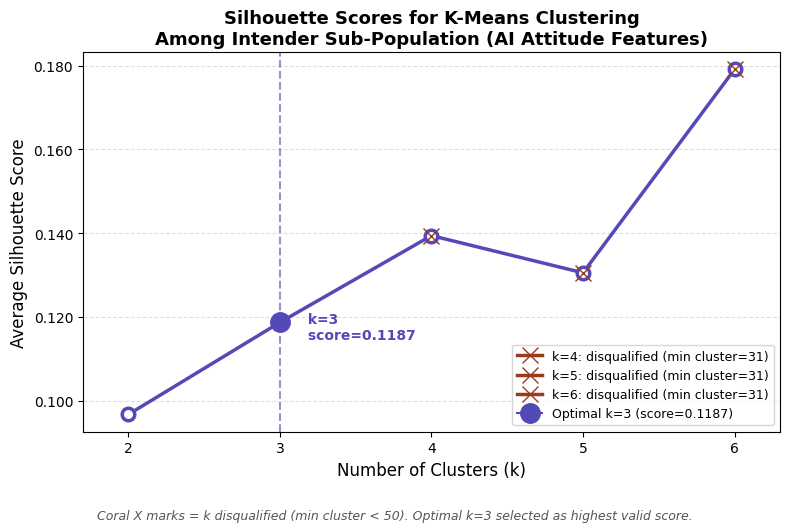

Saved: outputs/figures/clustering_silhouette.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Select optimal k: highest silhouette score among k values where
# every cluster has at least 50 intenders.
# Rationale: k=6 had the highest raw silhouette (0.1791) but produced
# a cluster of only 31 intenders — too small to profile reliably or
# target at PM scale. We apply the size floor before selecting k.
MIN_CLUSTER_SIZE = 50
valid_k = {k: s for k, s in silhouette_scores.items()
           if min_cluster_sizes[k] >= MIN_CLUSTER_SIZE}

if not valid_k:
    raise ValueError("No k value meets the minimum cluster size threshold.")

optimal_k = max(valid_k, key=valid_k.get)
optimal_score = silhouette_scores[optimal_k]

print(f"Valid k values (all clusters >= {MIN_CLUSTER_SIZE} intenders): {list(valid_k.keys())}")
print(f"Optimal k (highest silhouette among valid): {optimal_k}  (score={optimal_score:.4f})")
print()

# Build silhouette score plot
fig, ax = plt.subplots(figsize=(8, 5))
k_list = list(silhouette_scores.keys())
score_list = list(silhouette_scores.values())

# All k values as line
ax.plot(k_list, score_list, color="#534AB7", linewidth=2.5, marker="o",
        markersize=9, markerfacecolor="white",
        markeredgecolor="#534AB7", markeredgewidth=2.5, zorder=3)

# Mark disqualified k values (min cluster < 50) with a different style
for k in k_list:
    if min_cluster_sizes[k] < MIN_CLUSTER_SIZE:
        ax.plot(k, silhouette_scores[k], marker="x", markersize=12,
                color="#993C1D", linewidth=2.5, zorder=5,
                label=f"k={k}: disqualified (min cluster={min_cluster_sizes[k]})")

# Highlight optimal k
ax.plot(optimal_k, optimal_score, marker="o", markersize=14,
        color="#534AB7", zorder=6,
        label=f"Optimal k={optimal_k} (score={optimal_score:.4f})")
ax.axvline(x=optimal_k, color="#534AB7", linestyle="--", linewidth=1.5, alpha=0.6)
ax.annotate(
    f" k={optimal_k}\n score={optimal_score:.4f}",
    xy=(optimal_k, optimal_score),
    xytext=(optimal_k + 0.15, optimal_score - 0.004),
    fontsize=10, color="#534AB7", fontweight="bold"
)

ax.set_xlabel("Number of Clusters (k)", fontsize=12)
ax.set_ylabel("Average Silhouette Score", fontsize=12)
ax.set_title(
    "Silhouette Scores for K-Means Clustering\n"
    "Among Intender Sub-Population (AI Attitude Features)",
    fontsize=13, fontweight="bold"
)
ax.set_xticks(k_list)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_xlim(1.7, 6.3)

fig.text(
    0.5, -0.05,
    f"Coral X marks = k disqualified (min cluster < {MIN_CLUSTER_SIZE}). "
    f"Optimal k={optimal_k} selected as highest valid score.",
    ha="center", fontsize=9, color="#555555", style="italic"
)

plt.tight_layout()
plt.savefig("../outputs/figures/clustering_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/clustering_silhouette.png")


In [8]:
# Print silhouette scores summary table with size constraint status
print("=" * 60)
print(f"{'k':>4}  | {'Silhouette':>12}  | {'Min Cluster':>12}  | {'Status':>15}")
print("-" * 60)

for k in sorted(silhouette_scores.keys()):
    score = silhouette_scores[k]
    min_sz = min_cluster_sizes[k]
    if k == optimal_k:
        status_str = "<- OPTIMAL"
    elif min_sz < 50:
        status_str = "disqualified"
    else:
        status_str = "valid"
    print(f"  {k}  | {score:>12.4f}  | {min_sz:>12d}  | {status_str:>15}")

print("=" * 60)
print()
print(f"Optimal k selected: k={optimal_k}  (silhouette={optimal_score:.4f})")
print()

if optimal_score >= 0.3:
    interpretation = "Strong cluster structure."
elif optimal_score >= 0.2:
    interpretation = "Moderate cluster structure -- meaningful segments present."
elif optimal_score >= 0.1:
    interpretation = "Weak cluster structure -- segments exist but boundaries are diffuse."
else:
    interpretation = "Very weak structure -- intenders may be largely homogeneous."

print(f"Interpretation: {interpretation}")
print(f"Proceeding to Section 3 with k={optimal_k}.")


   k  |   Silhouette  |  Min Cluster  |          Status
------------------------------------------------------------
  2  |       0.0967  |          633  |           valid
  3  |       0.1187  |          153  |      <- OPTIMAL
  4  |       0.1394  |           31  |    disqualified
  5  |       0.1305  |           31  |    disqualified
  6  |       0.1791  |           31  |    disqualified

Optimal k selected: k=3  (silhouette=0.1187)

Interpretation: Weak cluster structure -- segments exist but boundaries are diffuse.
Proceeding to Section 3 with k=3.


---

## Section 3 — K-Means Clustering and Cluster Profiling

With optimal k=6 identified in Section 2, we now fit the final K-Means model and profile each cluster. The goal is to understand *who* is in each cluster and *what* distinguishes them — so we can assign a business-meaningful label and PM intervention to each group.

**A note on the silhouette scores:** All scores across k=2 through k=6 fell in the weak range (0.10–0.18). This is expected and not disqualifying for survey data with binary indicator features — human attitudes rarely cluster into perfectly separated groups. Weak silhouette scores mean the cluster boundaries are diffuse (some intenders sit near the border between two clusters) but not that the clusters are meaningless. We proceed and let the cluster profiles tell us whether the segments are interpretable and actionable. If profiles are indistinguishable across clusters, we will note that in a conclusion cell.

**How we interpret cluster profiles:** For each cluster we compute the mean of every attitude feature. Because all features are binary (0/1), the mean is simply the proportion of developers in that cluster who have that attribute — e.g., a mean of 0.62 on `LearnCodeAI_flag` means 62% of that cluster actively learned AI tooling. We compare these proportions across clusters to identify what makes each group distinctive.

**Step 3a — Fit the final K-Means model and assign cluster labels.**

In [9]:
# ── Fit final K-Means model ───────────────────────────────────────────────────
# Same hyperparameters used in the silhouette evaluation loop — n_init=20 ensures
# we pick the best of 20 random initializations, random_state=42 for reproducibility.
final_kmeans = KMeans(
    n_clusters=optimal_k,
    n_init=20,
    random_state=42
)
final_kmeans.fit(X_scaled)
cluster_labels = final_kmeans.labels_

# ── Attach cluster labels to the original (unscaled) intender DataFrame ──────
# We work with X_cluster (unscaled) for profiling so mean values are interpretable
# as proportions (0–1) rather than standardized scores.
X_intenders_clustered = X_cluster.copy()
X_intenders_clustered['cluster'] = cluster_labels

print(f"Cluster assignments attached. Total intenders: {len(X_intenders_clustered)}")
print(f"Unique clusters: {sorted(X_intenders_clustered['cluster'].unique())}")

Cluster assignments attached. Total intenders: 1437
Unique clusters: [np.int32(0), np.int32(1), np.int32(2)]


**Step 3b — Compute cluster sizes and print the profile table.**

The profile table shows the mean value of each attitude feature per cluster. For binary features, this is the proportion of developers in that cluster with that attribute (e.g., 0.65 = 65% of cluster members). We sort features within each attitude group for readability.

In [10]:
# ── Cluster sizes ─────────────────────────────────────────────────────────────
cluster_sizes = X_intenders_clustered['cluster'].value_counts().sort_index()

print("Cluster sizes:")
print("-" * 35)
for cluster_id, count in cluster_sizes.items():
    pct = count / len(X_intenders_clustered) * 100
    print(f"  Cluster {cluster_id}: {count:4d} intenders  ({pct:.1f}%)")
print("-" * 35)
print(f"  Total:   {len(X_intenders_clustered):4d} intenders (100.0%)")

# ── Cluster profiles — mean of each feature per cluster ───────────────────────
cluster_profiles = (
    X_intenders_clustered
    .groupby('cluster')[attitude_features]
    .mean()
    .round(3)
    .T  # features as rows, clusters as columns for readability
)

print()
print("Cluster profile table (mean proportion per feature):")
print("Values are proportions 0.0–1.0; higher = more common in that cluster")
print()

# Display with pandas for clean alignment
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 10)
print(cluster_profiles.to_string())

Cluster sizes:
-----------------------------------
  Cluster 0:  635 intenders  (44.2%)
  Cluster 1:  649 intenders  (45.2%)
  Cluster 2:  153 intenders  (10.6%)
-----------------------------------
  Total:   1437 intenders (100.0%)

Cluster profile table (mean proportion per feature):
Values are proportions 0.0–1.0; higher = more common in that cluster

cluster                                                             0     1     2
AIFrustration_AlmostRight                                       0.208 0.493 0.523
AIFrustration_DebuggingSlower                                   0.132 0.307 0.503
AIFrustration_DontUseRegularly                                  0.754 0.337 0.458
AIFrustration_HardToUnderstand                                  0.090 0.173 0.216
AIFrustration_LessConfident                                     0.038 0.160 0.111
AIFrustration_Other                                             0.033 0.042 0.144
AISent_Indifferent                                              0.318

**Step 3c — Cluster profile heatmap.**

The heatmap visualizes the same profile table above in a format easier to scan for patterns. Color intensity shows how prevalent each feature is within each cluster — darker purple = more common, lighter = less common. Clusters and features with similar colors are similar to each other.

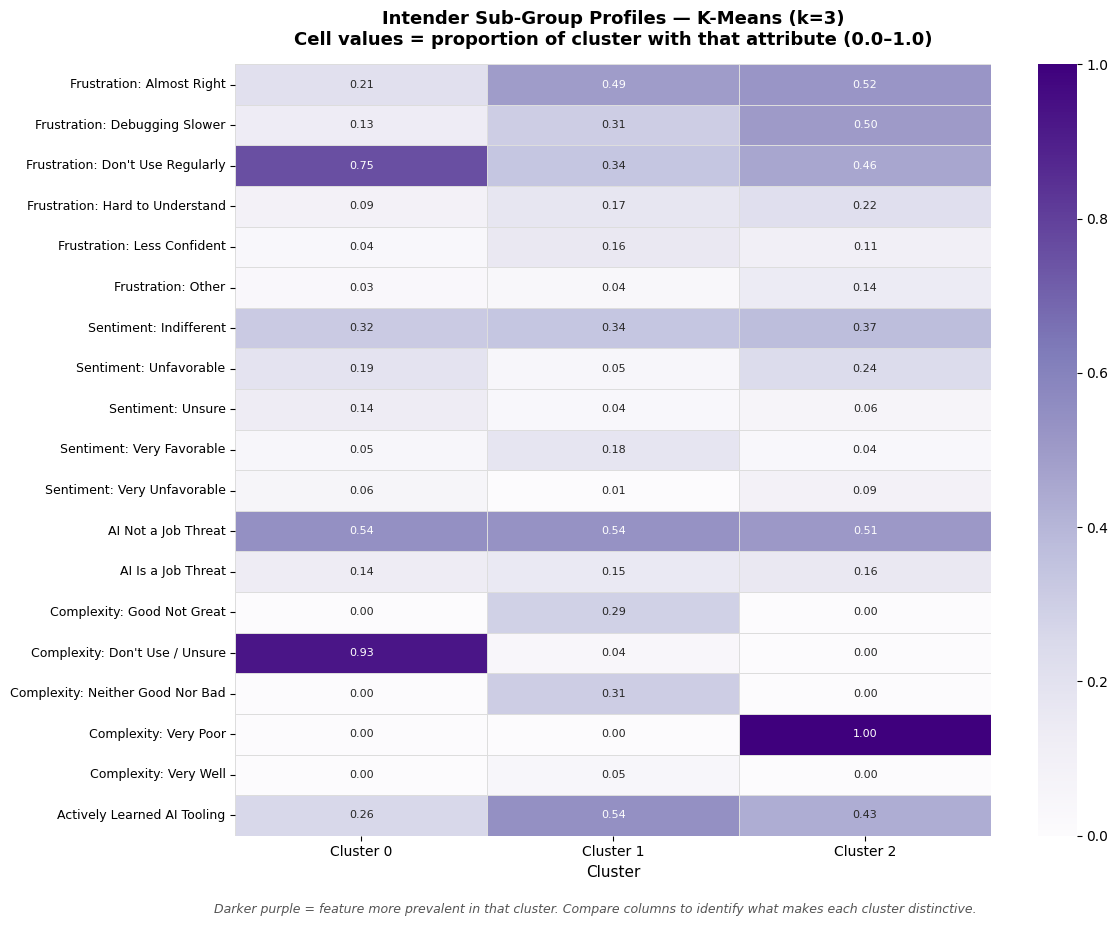

Saved: outputs/figures/clustering_cluster_profiles.png


In [11]:
import seaborn as sns

# ── Business-friendly feature label mapping ───────────────────────────────────
# Raw column names are not readable on a chart axis — map to plain English labels.
feature_label_map = {
    'AISent_Indifferent':                                    'Sentiment: Indifferent',
    'AISent_Unfavorable':                                    'Sentiment: Unfavorable',
    'AISent_Unsure':                                         'Sentiment: Unsure',
    'AISent_Very favorable':                                 'Sentiment: Very Favorable',
    'AISent_Very unfavorable':                               'Sentiment: Very Unfavorable',
    'AIThreat_No':                                           'AI Not a Job Threat',
    'AIThreat_Yes':                                          'AI Is a Job Threat',
    'AIComplex_Good, but not great at handling complex tasks':    'Complexity: Good Not Great',
    'AIComplex_I don\'t use AI tools for complex tasks / I don\'t know': 'Complexity: Don\'t Use / Unsure',
    'AIComplex_Neither good or bad at handling complex tasks':   'Complexity: Neither Good Nor Bad',
    'AIComplex_Very poor at handling complex tasks':             'Complexity: Very Poor',
    'AIComplex_Very well at handling complex tasks':             'Complexity: Very Well',
    'AIFrustration_AlmostRight':                             'Frustration: Almost Right',
    'AIFrustration_DebuggingSlower':                         'Frustration: Debugging Slower',
    'AIFrustration_DontUseRegularly':                        'Frustration: Don\'t Use Regularly',
    'AIFrustration_HardToUnderstand':                        'Frustration: Hard to Understand',
    'AIFrustration_LessConfident':                           'Frustration: Less Confident',
    'AIFrustration_Other':                                   'Frustration: Other',
    'LearnCodeAI_flag':                                      'Actively Learned AI Tooling',
}

# Apply labels to profile table rows
cluster_profiles_labeled = cluster_profiles.copy()
cluster_profiles_labeled.index = [
    feature_label_map.get(col, col) for col in cluster_profiles_labeled.index
]

# Column headers: "Cluster 0", "Cluster 1", etc.
cluster_profiles_labeled.columns = [f'Cluster {c}' for c in cluster_profiles_labeled.columns]

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    cluster_profiles_labeled,
    annot=True,
    fmt='.2f',
    cmap='Purples',       # consistent with project intender color
    linewidths=0.5,
    linecolor='#dddddd',
    ax=ax,
    vmin=0,
    vmax=1,
    annot_kws={'size': 8}
)

ax.set_title(
    f'Intender Sub-Group Profiles — K-Means (k={optimal_k})\n'
    'Cell values = proportion of cluster with that attribute (0.0–1.0)',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=10)

# Caption
fig.text(
    0.5, -0.02,
    'Darker purple = feature more prevalent in that cluster. '
    'Compare columns to identify what makes each cluster distinctive.',
    ha='center', fontsize=9, color='#555555', style='italic'
)

plt.tight_layout()
plt.savefig('../outputs/figures/clustering_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/clustering_cluster_profiles.png")

**Step 3d — Business labels and plain-English cluster summaries.**

Reading the profile table, each cluster has a clear defining feature — primarily driven by the `AIComplex` response (what the developer believes AI can do at complex tasks), with sentiment and frustration profile adding nuance. The six clusters are named and interpreted below.

In [12]:
# Cluster business labels (derived from reading the k=3 profile table above)
cluster_labels_map = {
    0: "Never-Started Intenders",
    1: "Engaged Fence-Sitters",
    2: "Quality-Disappointed Intenders",
}

print("=" * 60)
print(f"{'Cluster':<10} {'Label':<35} {'n':>5}  {'%':>6}")
print("-" * 60)
for cluster_id in sorted(cluster_labels_map.keys()):
    label = cluster_labels_map[cluster_id]
    n = cluster_sizes[cluster_id]
    pct = n / len(X_intenders_clustered) * 100
    print(f"  {cluster_id:<8} {label:<35} {n:>5}  {pct:>5.1f}%")
print("=" * 60)


Cluster    Label                                   n       %
------------------------------------------------------------
  0        Never-Started Intenders               635   44.2%
  1        Engaged Fence-Sitters                 649   45.2%
  2        Quality-Disappointed Intenders        153   10.6%


In [13]:
import textwrap

cluster_summaries = {
    0: {
        "label":     "Never-Started Intenders",
        "size_note": "635 intenders | 44.2% of intender training set -- LARGEST SEGMENT",
        "who": (
            "The dominant segment. Defined entirely by never having engaged with AI "
            "tools for complex tasks -- 93.2% selected \"I don't use AI tools for "
            "complex tasks / I don't know.\" Their biggest frustration is not using AI "
            "regularly (75.4%). Only 26.1% have actively learned AI tooling -- the "
            "lowest active-learning rate of any cluster. Sentiment is mixed: "
            "indifferent (31.8%), unfavorable (19.1%), unsure (13.5%)."
        ),
        "blocker": (
            "Pure inertia. They have not started. No trial, no opinion formed, no "
            "frustration from direct experience -- just absence of engagement. "
            "They intend to adopt but have not taken the first step. "
            "This is the activation gap in its purest form: intent without action."
        ),
        "pm_action": (
            "Remove the starting barrier entirely. The first interaction must "
            "require near-zero effort -- one-click install, zero-config trial, "
            "instant output with no setup required. This group will not seek out "
            "documentation or tutorials. If activation costs anything above "
            "'open it and type,' they stay in intent mode. "
            "Works for: frictionless trial design, IDE plugin default-on installs, "
            "'try it now' in-browser demos."
        ),
    },
    1: {
        "label":     "Engaged Fence-Sitters",
        "size_note": "649 intenders | 45.2% of intender training set",
        "who": (
            "Developers who have engaged with AI tools and formed a mixed but not "
            "negative view. AIComplex responses are distributed: Good but Not Great "
            "(29.1%), Neither Good Nor Bad (30.7%), with 4.8% rating it very well. "
            "They are the highest active-learning cluster (54.1%). "
            "Almost Right frustration is present (49.3%) but not dominant. "
            "Sentiment is more positive than other clusters -- 17.9% very favorable."
        ),
        "blocker": (
            "Ambivalence. They have tried AI, see some value, but lack a breakout "
            "moment that converts intent to committed use. The tool is working "
            "well enough to keep them engaged but not well enough to close the gap. "
            "They are the closest to crossing over of any segment -- high active "
            "learning, mixed-positive quality views, no strong negative signal."
        ),
        "pm_action": (
            "Provide a forced first win tailored to their workflow. This group has "
            "started exploring but needs a moment of undeniable usefulness to tip "
            "them into regular use. Use-case-specific onboarding (AI for code review, "
            "AI for documentation, AI for test scaffolding) will move them faster "
            "than generic demos. Power-user case studies from similar developers "
            "can provide the social proof this group responds to. "
            "Works for: targeted re-engagement campaigns, advanced onboarding flows, "
            "developer advocacy content."
        ),
    },
    2: {
        "label":     "Quality-Disappointed Intenders",
        "size_note": "153 intenders | 10.6% of intender training set",
        "who": (
            "Developers who have tried AI and found it genuinely poor at complex "
            "tasks -- 100% rated AIComplex as Very Poor. Almost Right frustration "
            "hits 52.3% and Debugging Slower hits 50.3% -- they are losing time "
            "fixing AI mistakes. Despite this, 43.1% are still actively learning, "
            "suggesting genuine intent to find a version of AI that works."
        ),
        "blocker": (
            "Reliability. They have tried AI, found it produces plausible-but-wrong "
            "outputs that cost more time to fix than to write from scratch. "
            "The frustration is earned and specific -- not fear of AI in the abstract "
            "but a concrete pattern of outputs that require rework. "
            "This finding is consistent with Act 2: the 'Almost Right' frustration "
            "had odds ratio 1.221 for intender status in the binary model."
        ),
        "pm_action": (
            "Lead onboarding with accuracy and transparency. Show confidence scores "
            "on outputs. Offer explanation modes. Steer toward use cases where AI "
            "reliability is highest -- boilerplate generation, documentation drafting, "
            "test scaffolding -- rather than complex reasoning tasks where it "
            "currently underdelivers. "
            "Messaging angle: 'built to work with you, not instead of you.' "
            "Works for: re-engagement of lapsed trial users, use-case targeting "
            "in onboarding, product confidence indicators."
        ),
    },
}

# Print plain-English summaries
for cluster_id, info in cluster_summaries.items():
    print("=" * 68)
    print(f"CLUSTER {cluster_id} -- {info['label']}")
    print(f"  {info['size_note']}")
    print()
    print("  WHO THEY ARE:")
    for line in textwrap.wrap(info["who"], width=65):
        print(f"    {line}")
    print()
    print("  WHAT BLOCKS THEM:")
    for line in textwrap.wrap(info["blocker"], width=65):
        print(f"    {line}")
    print()
    print("  PM INTERVENTION:")
    for line in textwrap.wrap(info["pm_action"], width=65):
        print(f"    {line}")
    print()


CLUSTER 0 -- Never-Started Intenders
  635 intenders | 44.2% of intender training set -- LARGEST SEGMENT

  WHO THEY ARE:
    The dominant segment. Defined entirely by never having engaged
    with AI tools for complex tasks -- 93.2% selected "I don't use AI
    tools for complex tasks / I don't know." Their biggest
    frustration is not using AI regularly (75.4%). Only 26.1% have
    actively learned AI tooling -- the lowest active-learning rate of
    any cluster. Sentiment is mixed: indifferent (31.8%), unfavorable
    (19.1%), unsure (13.5%).

  WHAT BLOCKS THEM:
    Pure inertia. They have not started. No trial, no opinion formed,
    no frustration from direct experience -- just absence of
    engagement. They intend to adopt but have not taken the first
    step. This is the activation gap in its purest form: intent
    without action.

  PM INTERVENTION:
    Remove the starting barrier entirely. The first interaction must
    require near-zero effort -- one-click install, zero

In [14]:
# Save cluster results to outputs/results/
results_rows = []
for cluster_id, info in cluster_summaries.items():
    n = cluster_sizes[cluster_id]
    pct = n / len(X_intenders_clustered) * 100
    results_rows.append({
        "cluster_id":    cluster_id,
        "label":         info["label"],
        "n_intenders":   n,
        "pct_of_total":  round(pct, 1),
        "primary_blocker": info["blocker"][:120].replace("\n", " "),
    })

results_df = pd.DataFrame(results_rows)
results_df.to_csv("../outputs/results/intender_clusters.csv", index=False)
print("Saved: outputs/results/intender_clusters.csv")
print()
print(results_df[["cluster_id", "label", "n_intenders", "pct_of_total"]].to_string(index=False))


Saved: outputs/results/intender_clusters.csv

 cluster_id                          label  n_intenders  pct_of_total
          0        Never-Started Intenders          635        44.200
          1          Engaged Fence-Sitters          649        45.200
          2 Quality-Disappointed Intenders          153        10.600
